Portfolio Project 2:



# Predicting Higher Perceived Stress Using Lifestyle and Behavioral Factors

## 1. Problem Definition

This project investigates whether sleep, behavioral, academic/work, and
lifestyle characteristics can be used to predict whether an individual
experiences a high level of stress.

The target variable is high stress, which will be represented as a binary
outcome:

- 0 = Not high stress
- 1 = High stress

Because the target variable consists of two categories, this is a binary
classification problem.

The primary model used in this project will be logistic regression. A
decision tree classifier will also be trained so that the performance of
two different classification approaches can be compared.

In [1508]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

## 2. Background and Context

Stress is an important issue among college students because students often have to balance academic responsibilities, social demands, sleep, and other aspects of daily life. Previous research suggests that everyday lifestyle and behavioral factors may be related to perceived stress, making these factors useful to examine when attempting to predict whether a student experiences higher perceived stress.

Sleep is one factor that may be particularly important. Huang et al. (2024) found a significant relationship between perceived stress and poorer sleep quality among college students. Physical activity and social behavior may also be related to stress. VanKim and Nelson (2013) found that college students who met vigorous physical activity recommendations were less likely to report perceived stress, while socializing played a role in the relationship between physical activity and mental well-being.

Caffeine use is another relevant behavior among university students. Kosecka et al. (2025) found that caffeine consumption was positively associated with perceived stress among university students. Based on this previous research, this project examines sleep duration, sleep quality, vigorous physical activity, caffeine use, and in-person social interaction as possible predictors of higher perceived stress.

### References

Huang, Y., Yang, L., Liu, Y., & Zhang, S. (2024). Effects of perceived stress on college students' sleep quality: A moderated chain mediation model. *BMC Psychology, 12*, 476. https://doi.org/10.1186/s40359-024-01976-3

VanKim, N. A., & Nelson, T. F. (2013). Vigorous physical activity, mental health, perceived stress, and socializing among college students. *American Journal of Health Promotion, 28*(1), 7–15. https://doi.org/10.4278/ajhp.111101-QUAN-395

Kosecka, O., Charzyńska, E., Czerwiński, S. K., Rudnik, A., & Atroszko, P. A. (2025). Caffeine intake mediates the relationship between problematic overstudying and psychological distress. Nutrients, 17(17), 2845. https://doi.org/10.3390/nu17172845

## 3. Data Description

The dataset used for this project was obtained from the Dryad Digital
Repository and contains survey-based information related to student health,
behavior, sleep, physical activity, social interaction, caffeine use, and
perceived stress. Each observation represents one weekly response for one
participant. Participants can and were encouraged to complete multiple 
surveys as a way to track their improvement.

The original dataset contains 3,841 observations and 91 variables. The
available variables cover multiple aspects of student behavior and well-being,
including sleep, physical activity, caffeine consumption, social interaction,
and perceived stress.

Perceived stress is measured using ten Perceived Stress Scale (PSS) survey
items. For this project, these items were combined to create an overall
perceived stress score. This score was then used to create the binary target
variable, where 0 represents lower perceived stress and 1 represents higher
perceived stress.

Five variables were ultimately selected as predictors: sleep duration, sleep
quality, vigorous physical activity, caffeine use, and in-person social
interaction. Some variables contain missing observations, which are addressed
during the data-preparation stage before modeling.

## 4. Data Understanding and Exploration

Before building the classification models, I explored the dataset to understand
its size, variables, data types, and potential missing values. This step will
help determine which variables are appropriate predictors of stress and what
preprocessing is necessary before modeling.

In [1509]:
df = pd.read_csv(r"C:\Users\theha\Downloads\survey_syn_5.csv")

In [1510]:
df.head()

,record_id,F1_App_numtakeoff,F1_App_sleeprecovery,F1_App_meditation,F1_App_breathwork,F1_App_periodpredictor,F1_App_otherring,F1_App_encourgesleep,F1_App_encouragemove,F1_App_encourageworkout,...,F1_GAD_nervous,F1_GAD_worry,F1_GAD_worrydifferent,F1_GAD_troublerelaxing,F1_GAD_restless,F1_GAD_annoyed,F1_GAD_afraid,F1_GAD_totalscore,F1_GAD_howdifficult,week
0,742.4,4.1,1.0,0,0,0,0.0,1,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
1,1356.8,2.9,1.0,0,0,0,0.0,1,0.0,0,...,2.0,1.0,2.0,1.0,1.0,0.0,0.0,7.0,1.0,5.0
2,742.4,7.7,0.0,0,0,0,0.0,0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
3,1049.6,4.1,0.0,0,0,0,0.0,0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
4,588.8,7.1,0.0,0,0,0,0.0,0,0.0,0,...,3.0,3.0,3.0,3.0,3.0,3.0,3.0,12.0,3.0,6.0


In [1511]:
print(df.shape)


(3852, 91)


In [1512]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3852 entries, 0 to 3851
Data columns (total 91 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   record_id                              3852 non-null   float64
 1   F1_App_numtakeoff                      3799 non-null   float64
 2   F1_App_sleeprecovery                   3828 non-null   float64
 3   F1_App_meditation                      3852 non-null   int64  
 4   F1_App_breathwork                      3852 non-null   int64  
 5   F1_App_periodpredictor                 3852 non-null   int64  
 6   F1_App_otherring                       3841 non-null   float64
 7   F1_App_encourgesleep                   3852 non-null   int64  
 8   F1_App_encouragemove                   3834 non-null   float64
 9   F1_App_encourageworkout                3852 non-null   int64  
 10  F1_App_encouragetakeeasy               3852 non-null   int64  
 11  F1_App_encourag

In [1513]:
df.isnull().sum()

record_id                 0
F1_App_numtakeoff        53
F1_App_sleeprecovery     24
F1_App_meditation         0
F1_App_breathwork         0
                       ... 
F1_GAD_annoyed          445
F1_GAD_afraid           423
F1_GAD_totalscore       404
F1_GAD_howdifficult     400
week                     11
Length: 91, dtype: int64

In [1514]:
stress_columns = [col for col in df.columns if "stress" in col.lower()]
stress_columns

['F1_Stress_stressevent',
 'F1_Stress_describeevent',
 'F1_Stress_stressacademic',
 'F1_Stress_stresspaper',
 'F1_PSS_stressupset',
 'F1_PSS_stresscontrol',
 'F1_PSS_stressnervous',
 'F1_PSS_stressconfident',
 'F1_PSS_stressthings',
 'F1_PSS_stresscope',
 'F1_PSS_stressirritations',
 'F1_PSS_stressontop',
 'F1_PSS_stressangered',
 'F1_PSS_stressdifficulties']

In [1515]:
work_school_columns = [
    col for col in df.columns
    if "work" in col.lower() or "school" in col.lower()
]

work_school_columns

['F1_App_breathwork',
 'F1_App_encourageworkout',
 'F1_Caffeine_workoutdrink',
 'F1_TimeOut_OutdoorWorkout']

In [1516]:
df["F1_PSS_stresscope"].value_counts(dropna=False).sort_index()

F1_PSS_stresscope
0.0     736
1.0    1080
2.0    1023
3.0     433
4.0     154
NaN     426
Name: count, dtype: int64

In [1517]:
df["F1_PSS_stresscope"].describe()

count    3426.000000
mean        1.471395
std         1.096204
min         0.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         4.000000
Name: F1_PSS_stresscope, dtype: float64

In [1518]:
pss_columns = [col for col in df.columns if "PSS" in col]
pss_columns

['F1_PSS_stressupset',
 'F1_PSS_stresscontrol',
 'F1_PSS_stressnervous',
 'F1_PSS_stressconfident',
 'F1_PSS_stressthings',
 'F1_PSS_stresscope',
 'F1_PSS_stressirritations',
 'F1_PSS_stressontop',
 'F1_PSS_stressangered',
 'F1_PSS_stressdifficulties']

### Creating a Perceived Stress Score

The dataset measures perceived stress using multiple survey questions scored on a 0–4 scale. Some questions are phrased in a positive direction, meaning that a higher response does not represent greater stress. These items need to be reverse-scored so that all of the questions point in the same direction.

For the reverse-scored items, each response is subtracted from 4. This means that a response of 0 becomes 4, 1 becomes 3, 2 remains 2, and so on. New columns are created for these reversed values so that the original survey responses remain unchanged.

After reverse scoring, the PSS items can be combined to create an overall perceived stress score, where higher scores represent greater perceived stress. 

In [1519]:
df["PSS_confident_rev"] = 4 - df["F1_PSS_stressconfident"]
df["PSS_things_rev"] = 4 - df["F1_PSS_stressthings"]
df["PSS_irritations_rev"] = 4 - df["F1_PSS_stressirritations"]
df["PSS_ontop_rev"] = 4 - df["F1_PSS_stressontop"]

In [1520]:
pss_scored = [
    "F1_PSS_stressupset",
    "F1_PSS_stresscontrol",
    "F1_PSS_stressnervous",
    "PSS_confident_rev",
    "PSS_things_rev",
    "F1_PSS_stresscope",
    "PSS_irritations_rev",
    "PSS_ontop_rev",
    "F1_PSS_stressangered",
    "F1_PSS_stressdifficulties"
]

df["PSS_total"] = df[pss_scored].sum(axis=1, min_count=10)

In [1521]:
df["PSS_total"].describe()

count    3283.000000
mean       15.863844
std         7.080888
min         0.000000
25%        11.000000
50%        16.000000
75%        21.000000
max        39.000000
Name: PSS_total, dtype: float64

In [1522]:
df["PSS_total"].isnull().sum()

np.int64(569)

### Distribution of Perceived Stress Scores

After calculating the total PSS score, I examined its distribution to better
understand the stress levels represented in the dataset. This visualization
helps identify the typical range of stress scores and will help determine an
appropriate way to define the target variable for the classification models.

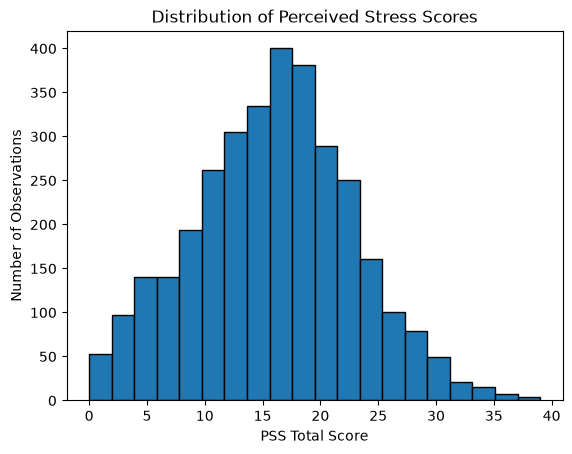

In [1523]:
plt.hist(df["PSS_total"].dropna(), bins=20, edgecolor="black")

plt.title("Distribution of Perceived Stress Scores")
plt.xlabel("PSS Total Score")
plt.ylabel("Number of Observations")

plt.show()

### Creating the Classification Target

To use logistic regression, the perceived stress score was converted into a
binary target variable. Observations with incomplete PSS scores were removed
before creating the target.

The median PSS score in the dataset was 16. For this project, individuals with
a PSS score of 16 or higher are classified as higher stress (1), while
individuals with a score below 16 are classified as lower stress (0).

The median was used as a project-specific threshold to create two reasonably
balanced groups for classification. This threshold is used for predictive
modeling and should not be interpreted as a clinical diagnosis of high stress.

In [1524]:
model_df = df.dropna(subset=["PSS_total"]).copy()

In [1525]:
model_df["high_stress"] = (model_df["PSS_total"] >= 16).astype(int)

In [1526]:
model_df["high_stress"].value_counts()

high_stress
1    1757
0    1526
Name: count, dtype: int64

In [1527]:
model_df["high_stress"].value_counts(normalize=True) * 100

high_stress
1    53.518124
0    46.481876
Name: proportion, dtype: float64

Selecting Predictor Variables

In [1528]:
sleep_columns = [col for col in model_df.columns if "sleep" in col.lower()]
sleep_columns

['F1_App_sleeprecovery',
 'F1_App_encourgesleep',
 'F1_Sleep_sleephours',
 'F1_Sleep_sleepquality',
 'F1_Sleep_sleepamount']

In [1529]:
activity_columns = [
    col for col in model_df.columns
    if "exercise" in col.lower() or "activity" in col.lower()
]

activity_columns

['F1_Activity_numvigorous',
 'F1_Activity_nummoderate',
 'F1_Activity_hoursminutes1',
 'F1_Activity_hoursminutes4',
 'F1_Activity_numwalking',
 'F1_Activity_hoursminutes2',
 'F1_Activity_hoursminutes3',
 'F1_Activity_hoursminutes5',
 'F1_Activity_hoursminutes6']

In [1530]:
academic_columns = [
    col for col in model_df.columns
    if "academic" in col.lower()
]

academic_columns

['F1_Stress_stressacademic']

In [1531]:
lifestyle_columns = [
    col for col in model_df.columns
    if "caffeine" in col.lower()
    or "alcohol" in col.lower()
    or "social" in col.lower()
    or "screen" in col.lower()
]

lifestyle_columns

['F1_Caffeine_caffeinethisweek',
 'F1_Caffeine_coffee',
 'F1_Caffeine_tea',
 'F1_Caffeine_soda',
 'F1_Caffeine_energydrink',
 'F1_Caffeine_workoutdrink',
 'F1_Caffeine_otherdrink',
 'F1_Caffeine_whencaffeineearly',
 'F1_Caffeine_whencaffeinemorning',
 'F1_Caffeine_whencaffeineafternoon',
 'F1_Caffeine_whencaffeinelateafternoon',
 'F1_Caffeine_whencaffeineevening',
 'F1_Caffeine_whencaffeinenight',
 'F1_Caffeine_whycaffeineawake',
 'F1_Caffeine_whycaffeinestayup',
 'F1_Caffeine_whycaffeinefocus',
 'F1_Caffeine_whycaffeinealert',
 'F1_Caffeine_whycaffeineproductive',
 'F1_Caffeine_whycaffeinephysical',
 'F1_Caffeine_whycaffeinenonspecific',
 'F1_Caffeine_whycaffeinenoanswer',
 'F1_Caffeine_whycaffeineother',
 'F1_Social_numbersocial',
 'F1_Social_howmanyfriends',
 'F1_Social_howmmanyinperson',
 'F1_Social_videocall',
 'F1_Social_phone',
 'F1_Social_talkfamily',
 'F1_Social_moreorless']

In [1532]:
time_columns = [
    col for col in model_df.columns
    if "hour" in col.lower()
    or "study" in col.lower()
    or "work" in col.lower()
]

time_columns

['F1_App_breathwork',
 'F1_App_encourageworkout',
 'F1_Activity_hoursminutes1',
 'F1_Activity_hoursminutes4',
 'F1_Activity_hoursminutes2',
 'F1_Activity_hoursminutes3',
 'F1_Activity_hoursminutes5',
 'F1_Activity_hoursminutes6',
 'F1_Caffeine_workoutdrink',
 'F1_TimeOut_Hours',
 'F1_TimeOut_OutdoorWorkout',
 'F1_Sleep_sleephours']

### Feature Selection

Five lifestyle and behavioral variables were selected as potential predictors
of higher perceived stress: sleep duration, sleep quality, vigorous physical
activity, caffeine use, and in-person social interaction.

These variables were selected because they represent different aspects of
daily behavior that may be associated with stress.

In [1533]:
features = [
    "F1_Sleep_sleephours",
    "F1_Sleep_sleepquality",
    "F1_Activity_numvigorous",
    "F1_Caffeine_caffeinethisweek",
    "F1_Social_howmmanyinperson"
]

model_df[features].describe()

,F1_Sleep_sleephours,F1_Sleep_sleepquality,F1_Activity_numvigorous,F1_Caffeine_caffeinethisweek,F1_Social_howmmanyinperson
count,3268.000000,3281.000000,3249.000000,3278.000000,3203.000000
mean,7.105018,2.284365,1.619267,0.590604,8.551421
std,1.237962,0.667103,1.831413,0.491797,4.041025
min,4.600000,1.000000,0.000000,0.000000,4.600000
25%,7.000000,2.000000,0.000000,0.000000,4.600000
50%,7.000000,2.000000,1.000000,1.000000,7.000000
75%,8.200000,3.000000,3.000000,1.000000,10.600000
max,11.800000,4.000000,7.000000,1.000000,15.400000


In [1534]:
model_df[features].isnull().sum()

F1_Sleep_sleephours             15
F1_Sleep_sleepquality            2
F1_Activity_numvigorous         34
F1_Caffeine_caffeinethisweek     5
F1_Social_howmmanyinperson      80
dtype: int64

In [1535]:
for column in features:
    print("\n", column)
    print(model_df[column].value_counts(dropna=False).sort_index())


 F1_Sleep_sleephours
F1_Sleep_sleephours
4.6      201
5.8      615
7.0     1454
8.2      764
9.4      177
10.6      43
11.8      14
NaN       15
Name: count, dtype: int64

 F1_Sleep_sleepquality
F1_Sleep_sleepquality
1.0     268
2.0    1940
3.0     945
4.0     128
NaN       2
Name: count, dtype: int64

 F1_Activity_numvigorous
F1_Activity_numvigorous
0.0    1355
1.0     488
2.0     487
3.0     381
4.0     207
5.0     187
6.0     115
7.0      29
NaN      34
Name: count, dtype: int64

 F1_Caffeine_caffeinethisweek
F1_Caffeine_caffeinethisweek
0.0    1342
1.0    1936
NaN       5
Name: count, dtype: int64

 F1_Social_howmmanyinperson
F1_Social_howmmanyinperson
4.6     1127
5.8      261
7.0      270
8.2      235
9.4      137
10.6     401
11.8      90
13.0      58
14.2      74
15.4     550
NaN       80
Name: count, dtype: int64


### Preparing the Data for Modeling

Before training the machine learning models, observations with missing values
in the selected predictor variables were removed. Because the amount of missing
data was relatively small compared with the overall dataset, I felt it was best to 
analyze the complete cases to ensure the conclusion is a direct representation of 
the dataset. Rather than estimating missing values.


In [1536]:
model_clean = model_df.dropna(subset=features).copy()

print("Observations before cleaning:", len(model_df))
print("Observations after cleaning:", len(model_clean))

Observations before cleaning: 3283
Observations after cleaning: 3171


Define X and Y

In [1537]:
X = model_clean[features]
y = model_clean["high_stress"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3171, 5)
y shape: (3171,)


In [1538]:
y.value_counts()

high_stress
1    1695
0    1476
Name: count, dtype: int64

### Checking for Repeated Observations

Before splitting the data into training and testing sets, I checked whether
record IDs appeared more than once in the dataset. This is important because
repeated observations from the same individual should not be placed in both
the training and testing sets, as this could lead to data leakage and make
model performance appear better than it actually is.

In [1539]:
print("Total observations:", len(model_clean))
print("Unique record IDs:", model_clean["record_id"].nunique())
print("Repeated record IDs:", model_clean["record_id"].duplicated().sum())

Total observations: 3171
Unique record IDs: 8
Repeated record IDs: 3163


In [1540]:
model_clean[["record_id", "week"]].value_counts().sort_index()

record_id  week
588.8      1.0     218
           2.0      65
           3.0     208
           4.0     185
           5.0     179
                  ... 
1664.0     4.0       1
           5.0       5
           6.0       2
           7.0       1
           8.0       4
Name: count, Length: 63, dtype: int64

In [1541]:
print("Unique weeks:", model_clean["week"].nunique())
print("Week values:", sorted(model_clean["week"].unique()))

Unique weeks: 8
Week values: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0)]


In [1542]:
model_clean.groupby("record_id").size()

record_id
588.8     1325
742.4      267
896.0      298
1049.6     267
1203.2     365
1356.8     498
1510.4     132
1664.0      19
dtype: int64

In [1543]:
model_clean["F1_Activity_numvigorous"].value_counts().sort_index()

F1_Activity_numvigorous
0.0    1334
1.0     466
2.0     475
3.0     377
4.0     190
5.0     186
6.0     114
7.0      29
Name: count, dtype: int64

In [1544]:
print(
    "Values above 7:",
    (model_clean["F1_Activity_numvigorous"] > 7).sum()
)

Values above 7: 0


## 5. Training and Testing Strategy

The cleaned dataset was divided into training and testing sets. Eighty percent
of the observations were used to train the models, while the remaining 20
percent were reserved for testing.

A stratified split was used so that the proportion of higher-stress and
lower-stress observations remained similar in both sets. 

In [1545]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

Training observations: 2536
Testing observations: 635


In [1546]:
print("Training target proportions:")
print(y_train.value_counts(normalize=True))

print("\nTesting target proportions:")
print(y_test.value_counts(normalize=True))

Training target proportions:
high_stress
1    0.5347
0    0.4653
Name: proportion, dtype: float64

Testing target proportions:
high_stress
1    0.533858
0    0.466142
Name: proportion, dtype: float64


## 6. Model Development

### Logistic Regression

Logistic regression was selected as the first classification model because the
target variable has two possible outcomes: higher stress or lower stress. The
model will use the five selected lifestyle and behavioral variables to estimate
the probability that an observation belongs to the higher-stress group.

In [1547]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [1548]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()

log_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

In [1549]:
y_pred_log = log_model.predict(X_test_scaled)

print(y_pred_log[:20])

[1 1 0 1 0 1 0 1 0 1 1 1 0 1 1 1 0 1 1 0]


In [1550]:
from sklearn.metrics import accuracy_score

log_accuracy = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", log_accuracy)

Logistic Regression Accuracy: 0.5559055118110237


The Logistic regression model achieved an accuracy of approximately 55.6% on
the testing data. This means that the model correctly classified about 56% of
the observations as either higher or lower perceived stress.

It's important to note the majority class represents approximately 53.4% of the testing data, so the
logistic regression model performed slightly better than simply predicting the
most common class. The relatively small improvement suggests that the
five selected lifestyle and behavioral variables have limited predictive power
when used in a logistic regression model.

In [1551]:
from sklearn.metrics import precision_score, recall_score, f1_score

log_precision = precision_score(y_test, y_pred_log)
log_recall = recall_score(y_test, y_pred_log)
log_f1 = f1_score(y_test, y_pred_log)

print("Accuracy:", log_accuracy)
print("Precision:", log_precision)
print("Recall:", log_recall)
print("F1 Score:", log_f1)

Accuracy: 0.5559055118110237
Precision: 0.5629139072847682
Recall: 0.7522123893805309
F1 Score: 0.6439393939393939


In [1552]:
from sklearn.metrics import confusion_matrix

log_cm = confusion_matrix(y_test, y_pred_log)

print(log_cm)

[[ 98 198]
 [ 84 255]]


### Logistic Regression Evaluation

The logistic regression model achieved 55.6% accuracy, 56.3% precision,
75.2% recall, and an F1 score of 64.4%.

The model had relatively high recall, meaning that it successfully identified
about 75% of the observations that actually belonged to the higher-stress
group. However, the model also produced many false positives, incorrectly
classifying 198 lower-stress observations as higher stress.

Overall, the model appears better at identifying higher-stress observations
than distinguishing between the two stress groups in general.

### Decision Tree 

I selected a decision tree as the second model because it is the
perfect compliment to logistic regression. Unlike logistic regression, a
decision tree can identify nonlinear relationships and interactions between
predictor variables.

In [1553]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

In [1554]:
tree_accuracy = accuracy_score(y_test, y_pred_tree)
tree_precision = precision_score(y_test, y_pred_tree)
tree_recall = recall_score(y_test, y_pred_tree)
tree_f1 = f1_score(y_test, y_pred_tree)

print("Accuracy:", tree_accuracy)
print("Precision:", tree_precision)
print("Recall:", tree_recall)
print("F1 Score:", tree_f1)

Accuracy: 0.5433070866141733
Precision: 0.5698005698005698
Recall: 0.5899705014749262
F1 Score: 0.5797101449275363


In [1555]:
tree_cm = confusion_matrix(y_test, y_pred_tree)

print(tree_cm)

[[145 151]
 [139 200]]


## 7. Model Comparison

The logistic regression and decision tree models were evaluated using accuracy,
precision, recall, and F1 score.

Logistic regression achieved an accuracy of 55.6%, compared with 54.3% for the
decision tree. Logistic regression also had substantially higher recall
(75.2% vs. 59.0%) and a higher F1 score (64.4% vs. 58.0%). The decision tree
had slightly higher precision (57.0% vs. 56.3%).

Overall, logistic regression was selected as the better-performing model.
Although its overall accuracy was modest, it was more successful at identifying
observations in the higher-stress group and produced the stronger F1 score.

In [1556]:
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": log_model.coef_[0]
})

coefficients["Absolute Coefficient"] = coefficients["Coefficient"].abs()

coefficients = coefficients.sort_values(
    "Absolute Coefficient",
    ascending=False
)

coefficients

,Feature,Coefficient,Absolute Coefficient
3,F1_Caffeine_caffeinethisweek,0.140277,0.140277
0,F1_Sleep_sleephours,-0.101686,0.101686
1,F1_Sleep_sleepquality,0.089856,0.089856
4,F1_Social_howmmanyinperson,-0.045384,0.045384
2,F1_Activity_numvigorous,0.035484,0.035484


| Predictor | Coefficient | Interpretation |
|---|---:|---|
| Caffeine use | +0.140 | Strongest positive association with higher stress |
| Sleep hours | -0.102 | More sleep associated with lower stress |
| Sleep quality | +0.090 | Positive association with higher stress |
| In-person social interaction | -0.045 | More interaction associated with lower stress |
| Vigorous activity | +0.035 | Weakest association |

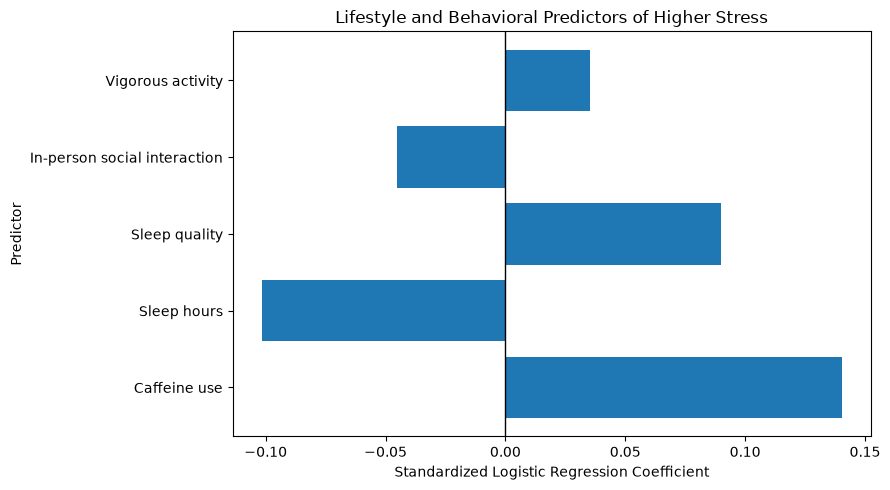

In [1557]:
# Create cleaner names for the predictors
clean_names = {
    "F1_Caffeine_caffeinethisweek": "Caffeine use",
    "F1_Sleep_sleephours": "Sleep hours",
    "F1_Sleep_sleepquality": "Sleep quality",
    "F1_Social_howmmanyinperson": "In-person social interaction",
    "F1_Activity_numvigorous": "Vigorous activity"
}

# Create a column with the cleaner names
coefficients["Predictor"] = coefficients["Feature"].replace(clean_names)

# Create the graph
plt.figure(figsize=(9, 5))

plt.barh(
    coefficients["Predictor"],
    coefficients["Coefficient"]
)

plt.axvline(0, color="black", linewidth=1)

plt.xlabel("Standardized Logistic Regression Coefficient")
plt.ylabel("Predictor")
plt.title("Lifestyle and Behavioral Predictors of Higher Stress")

plt.tight_layout()
plt.show()

## 8. Ethics and Limitations

This project has several important limitations. First, the dataset contains
self-reported information about behaviors such as sleep, caffeine use, physical
activity, social interaction, and perceived stress. Self-reported data may be
affected by inaccurate recall or differences in how individuals interpret
survey questions.

The stress classification used in this project is also not a clinical
diagnosis. Higher stress was defined using the median PSS score in this dataset,
with scores of 16 or greater classified as higher perceived stress. Therefore,
the model should not be used to diagnose an individaul's mental health
or determine if someone needs medical treatment.

The models also showed relatively limited predictive performance. Logistic
regression, the better-performing model, achieved approximately 55.6% accuracy.
This suggests that the five selected lifestyle and behavioral variables alone
do not provide enough information to reliably predict perceived stress.

There are also ethical concerns when using machine learning to predict
mental-health-related outcomes. False negatives could fail to identify someone
experiencing higher stress, while false positives could incorrectly label
someone as experiencing higher stress. In this case limiting the false negatives
is extremely important because an unidentified high stress situation can potentially
compound into something much worse. For this reason, a model such as this
should be viewed as an exploratory research tool rather than a replacement for
professional mental health assessment.

Finally, the relationships identified by the models are associations and
should not be interpreted as causal relationships. For example, the model
found an association between caffeine use and higher perceived stress, but this
does not demonstrate that caffeine consumption causes higher stress.

## 9. Conclusion

This project examined whether five lifestyle and behavioral characteristics
could predict higher perceived stress. Logistic regression and a decision tree
classifier were compared using the same training and testing data.

Logistic regression performed better overall, achieving 55.6% accuracy and an
F1 score of 64.4%. The model was particularly successful at identifying
higher-stress observations, with a recall of 75.2%. Among the selected
predictors, caffeine use and sleep duration had the strongest relationships
with the predicted stress classification.

Overall, the results suggest that lifestyle and behavioral factors contain
some information related to perceived stress, but the selected variables alone
are not sufficient for highly accurate prediction. Future models could examine
additional predictors or alternative modeling approaches while continuing to
consider the ethical limitations of predicting mental-health-related outcomes.

10. Code and AI Transparency 

### Code
The complete Jupyter Notebook containing the Python code used for data
preparation, exploration, modeling, evaluation, and visualization is available
through my GitHub portfolio.

**GitHub Repository:** [Insert GitHub repository link here]

### Data Source
The dataset used in this project was obtained from the Dryad Digital Repository.

**Dataset:** https://doi.org/10.5061/dryad.zgmsbcct8

### AI Usage Disclosure
OpenAI was used as a support tool during this project.
It was used to help explain Python concepts, troubleshoot code, organize the
analysis, and assist in creating new code that was necceasary to complete
the project as effectively as possible. All code was
reviewed and executed by me, and modeling decisions and interpretations were
based on the results produced in my Jupyter Notebook.